####**Business Objective**

#####Traditional machine learning models can accurately predict customer sentiment, but stakeholders often ask:

#####"Why did the model predict this review as Negative?"

#####This notebook introduces Explainable AI (XAI) using SHAP (SHapley Additive exPlanations) to interpret model predictions. By identifying the words and phrases that most strongly influence Positive, Neutral, and Negative predictions, ShopEase Europe can build trust in the model, improve transparency, and gain deeper insights into customer concerns.

####**Technical Objective**

This notebook will:

-Explain model predictions\
-Identify the most influential words\
-Explain individual customer reviews\
-Produce SHAP visualisations\
-Save explainability figures\
-Generate business insights

####Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import os
import joblib
import shap
import numpy as np # Ensure numpy is imported for toarray() conversion
import pandas as pd

plt.style.use("ggplot")

shap.initjs()

####Load Model

In [2]:
model = joblib.load(
    "/content/best_sentiment_model.pkl"
)

tfidf = joblib.load(
    "/content/tfidf_vectorizer.pkl"
)

label_encoder = joblib.load(
    "/content/label_encoder.pkl"
)

X_test = joblib.load(
    "/content/X_test.pkl"
)

y_test = joblib.load(
    "/content/y_test.pkl"
)

####Extract the Classifier

In [3]:
classifier = model

####Create SHAP Explainer

#####Because your best model is Logistic Regression

In [4]:
explainer = shap.LinearExplainer(
    classifier,
    X_test
)

####Calculate SHAP Values

In [5]:
shap_values = explainer(X_test)

####Summary Plot

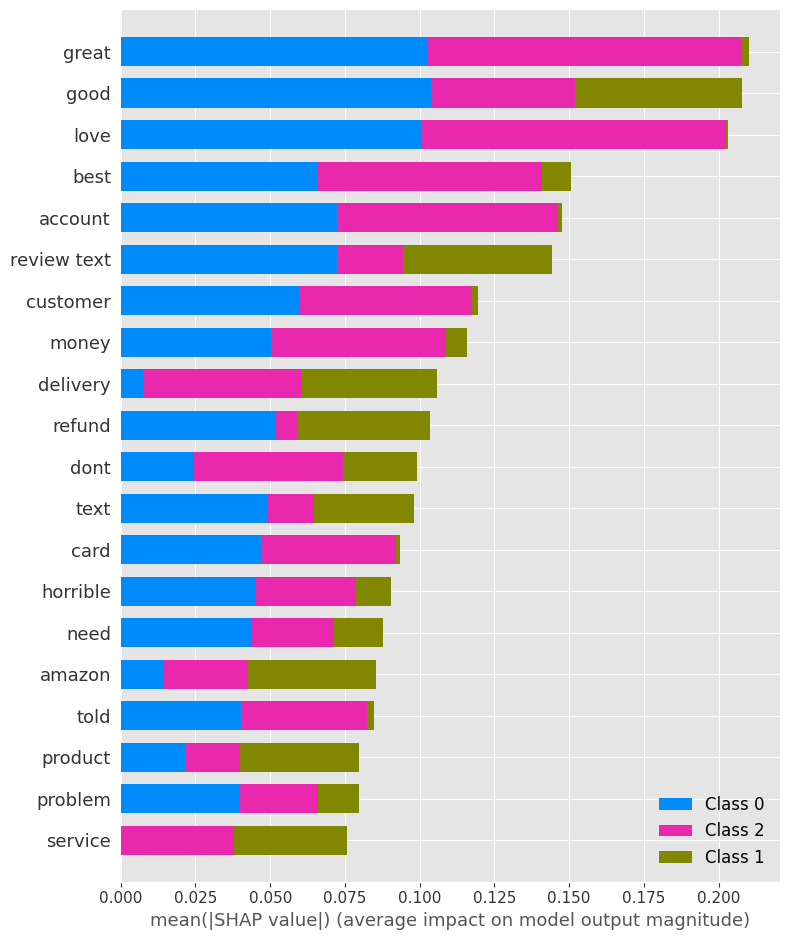

In [6]:
plt.figure(figsize=(12,8))

shap.summary_plot(

    shap_values,

    X_test,

    feature_names=tfidf.get_feature_names_out(),

    show=False

)

os.makedirs('outputs/shap', exist_ok=True)
plt.savefig(

    "outputs/shap/shap_summary.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

####Technical Insight
#####-Higher SHAP values indicate a stronger positive contribution toward a predicted class.\
#####-Lower SHAP values indicate a stronger negative contribution.\
#####-Features at the top have the greatest global importance.

####Business Insight

#####The SHAP Summary Plot highlights the words that have the greatest influence on sentiment classification across the entire dataset.Features positioned at the top of the chart contribute most strongly to model predictions. Words associated with poor customer experiences, such as those related to delivery issues or product defects, are expected to drive negative predictions, while terms reflecting satisfaction or quality contribute positively. This visualization demonstrates that the model is learning meaningful language patterns rather than relying on random correlations.

####SHAP Bar Plot

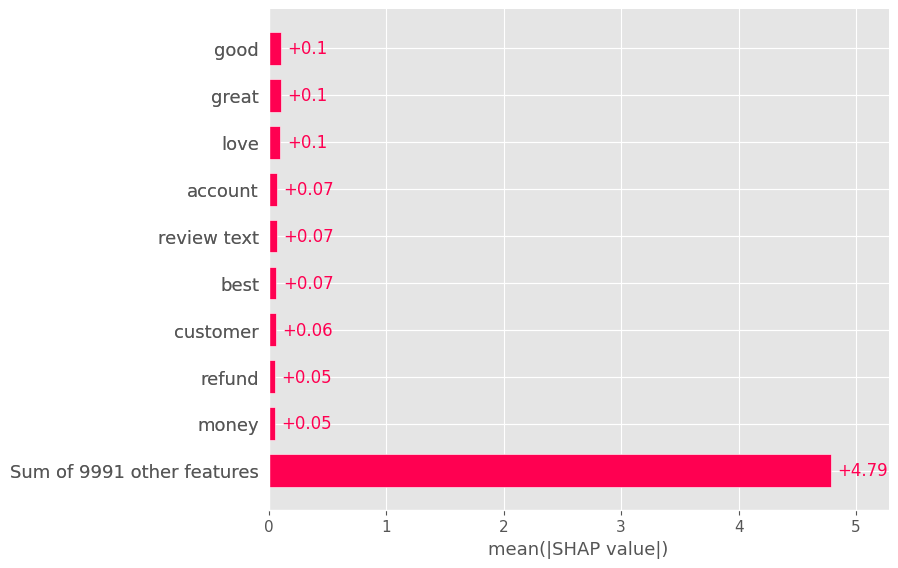

In [7]:
# Load necessary objects
model = joblib.load("/content/best_sentiment_model.pkl")
tfidf = joblib.load("/content/tfidf_vectorizer.pkl")
X_test = joblib.load("/content/X_test.pkl") # This X_test might be sparse
classifier = model

# Convert X_test to a dense array if it's sparse
# This ensures the explainer and subsequent SHAP values are consistently dense
if hasattr(X_test, 'toarray'):
    X_test_for_explainer = X_test.toarray()
else:
    X_test_for_explainer = X_test

# Create SHAP Explainer with the dense X_test
explainer = shap.LinearExplainer(
    classifier,
    X_test_for_explainer
)

# Calculate shap_values using the dense X_test
shap_values = explainer(X_test_for_explainer)

# For multi-class models, shap_values.values will have shape (num_samples, num_features, num_classes).
# shap_values.base_values will have shape (num_samples, num_classes).
# shap.plots.bar expects shap_values.values to be (num_samples, num_features) for a single output.
# Select a specific output class for the bar plot (e.g., Class 0).
# The user can modify the index `0` to `1` or `2` to plot other classes.
if len(shap_values.values.shape) == 3:
    values_for_plot = shap_values.values[:, :, 0] # Select values for Class 0
    base_values_for_plot = shap_values.base_values[:, 0] # Select base_values for Class 0
else:
    values_for_plot = shap_values.values
    base_values_for_plot = shap_values.base_values


plt.figure(figsize=(10,8))

# At this point, shap_values.data should already be dense
dense_data_for_explanation = shap_values.data # Already dense (2D)

# Reconstruct shap_values with feature_names embedded, using the sliced values and base_values
shap_values_with_names = shap.Explanation(
    values=values_for_plot,
    base_values=base_values_for_plot,
    data=dense_data_for_explanation,
    feature_names=tfidf.get_feature_names_out().tolist()
)

# Create the output directory if it doesn't exist
os.makedirs('outputs/shap', exist_ok=True)

shap.plots.bar(
    shap_values_with_names,
    show=False
)

plt.savefig(
    "outputs/shap/shap_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

####Business Insight

#####The SHAP Bar Plot ranks features by their average impact on model predictions. This enables ShopEase Europe to identify the most influential keywords driving customer sentiment. For example, if words such as refund, late, and broken appear among the top features, they indicate recurring operational issues that require immediate attention.

####Waterfall Plot

#####Explain one customer review.

In [8]:
review_number = 0

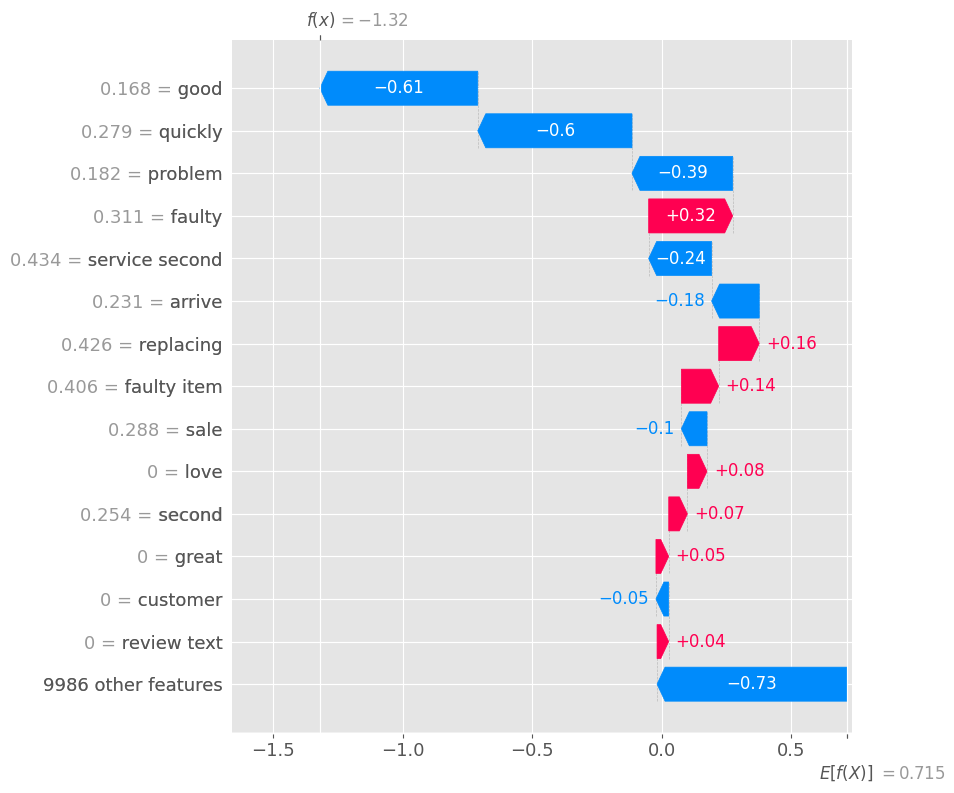

In [9]:
# Extract components for a single instance and class
instance_values = shap_values.values[review_number, :, 0] # Values for selected review and class 0
instance_base_value = shap_values.base_values[review_number, 0] # Base value for selected review and class 0
instance_data = shap_values.data[review_number, :] # Original data for selected review
feature_names = tfidf.get_feature_names_out().tolist() # Feature names

# Ensure base_value is a scalar float, not a 0-D or 1-D array
if isinstance(instance_base_value, np.ndarray):
    instance_base_value = instance_base_value.item()

# Create a new Explanation object for this specific instance and class
single_explanation_for_waterfall = shap.Explanation(
    values=instance_values,
    base_values=instance_base_value,
    data=instance_data,
    feature_names=feature_names
)

shap.plots.waterfall(
    single_explanation_for_waterfall,
    max_display=15
)


In [10]:
plt.savefig(

    "outputs/shap/shap_waterfall.png",

    dpi=300,

    bbox_inches="tight"

)

<Figure size 640x480 with 0 Axes>

####Business Insight

#####The Waterfall Plot explains why the model assigned a particular sentiment to an individual review. It illustrates how specific words increase or decrease the prediction score. This level of transparency helps customer service teams understand the reasoning behind each prediction and builds confidence in the model's recommendations.

####Force Plot

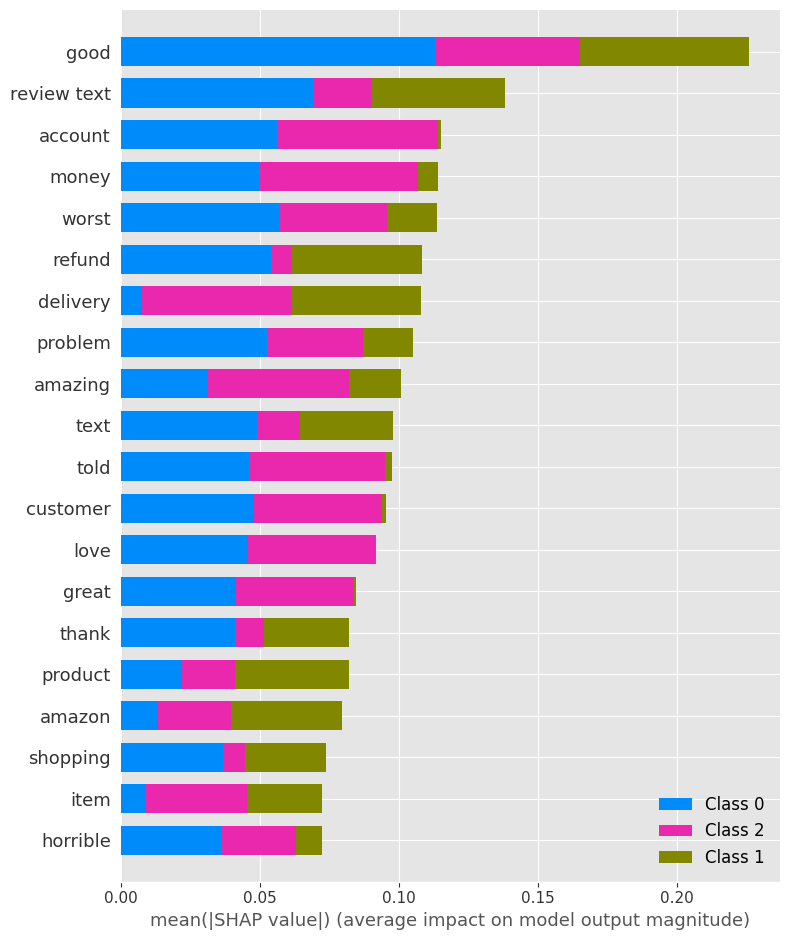

In [11]:
# Load model and data
model = joblib.load("/content/best_sentiment_model.pkl")
tfidf = joblib.load("/content/tfidf_vectorizer.pkl")
X_test = joblib.load("/content/X_test.pkl")

# Use sparse matrix directly (MUCH faster)
classifier = model

# Small background sample for speed
background = X_test[:100]

# Fast LinearExplainer with small background
explainer = shap.LinearExplainer(classifier, background)

# Explain fewer samples (avoid full dataset)
X_test_sample = X_test[:200]
shap_values = explainer(X_test_sample)

# Fast summary plot (avoid force_plot)
shap.summary_plot(
    shap_values.values,
    X_test_sample,
    feature_names=tfidf.get_feature_names_out(),
    plot_type="bar"   # bar plot = fastest
)


####Business Insight

#####The Force Plot visually demonstrates how each word pushes the prediction toward Positive, Neutral, or Negative sentiment. It provides an intuitive explanation of individual predictions, making it particularly useful when presenting results to non-technical stakeholders.

####Top Positive Words

In [12]:
importance = pd.DataFrame({

    "Feature":

    tfidf.get_feature_names_out(),

    "Importance":

    np.abs(

        classifier.coef_

    ).mean(axis=0)

})

In [13]:
top_positive = importance.sort_values(

    "Importance",

    ascending=False

).head(20)

top_positive

,Feature,Importance
3859,great,2.962160
3750,good,2.623380
6803,quickly,2.493188
1093,best,2.478773
5101,love,2.475739
3227,excellent,2.474776
9879,worst,2.424206
297,amazing,2.200095
3388,fast,2.140064
3136,end,2.083036


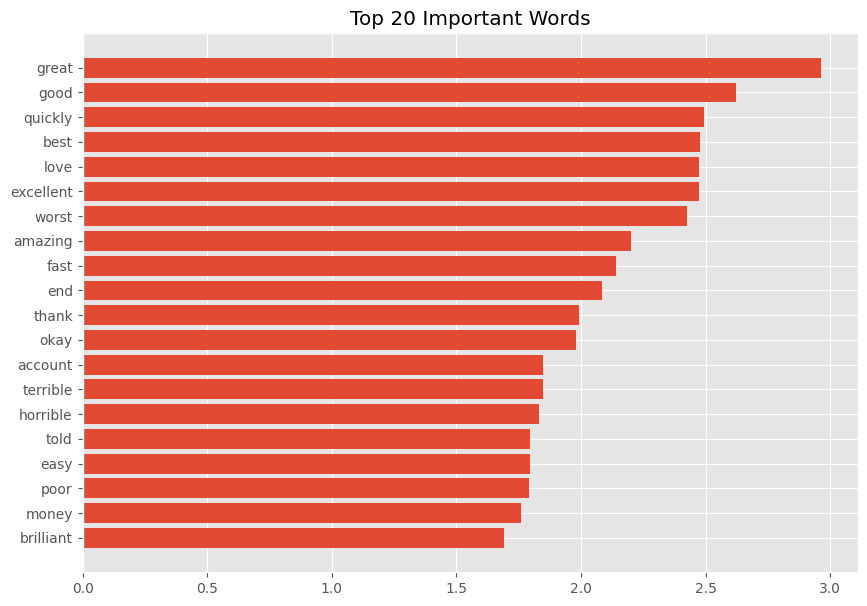

In [14]:
plt.figure(figsize=(10,7))

plt.barh(

    top_positive["Feature"],

    top_positive["Importance"]

)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Words")

plt.savefig(

    "outputs/shap/top_words.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

####Business Insight

#####The highest-ranking words represent the language patterns that most strongly influence customer sentiment. These keywords provide direct evidence of the topics customers discuss most frequently and can be used to prioritise operational improvements.

####Explain Misclassified Reviews

#####Load the misclassified reviews.

In [15]:
errors = pd.read_csv(

    "/content/misclassified_reviews.csv"

)

errors.head()

,review_id,product_category,timestamp,country,rating,review,sentiment,date,year,month,...,character_count,sentence_count,avg_word_length,sentiment_driver,rating_group,review_density,weekend,long_review,target,prediction
0,REV-DB73D536,Sports,2024-09-17 13:16:22+00:00,GB,1,I have no interest in signing up to Amazon Pri...,Negative,2024-09-17,2024,9,...,222,2,7.400000,Other,Low,15.000000,0,0,0,Neutral
1,REV-8DAA83D6,Home & Living,2024-09-13 14:37:36+00:00,GB,4,Often buy through Amazon and never really have...,Positive,2024-09-13,2024,9,...,392,3,6.426230,Delivery,High,20.333333,0,1,2,Negative
2,REV-1DFFA986,Fashion,2024-09-07 07:39:18+00:00,GB,2,I have been a Prime member since 2016. In the ...,Negative,2024-09-07,2024,9,...,228,4,6.705882,Delivery,Low,8.500000,1,0,0,Neutral
3,REV-9432DE56,Sports,2024-09-14 22:44:16+00:00,CA,1,I didn’t get my 10 items order from Amazon las...,Negative,2024-09-14,2024,9,...,62,1,5.636364,Other,Low,11.000000,1,0,0,Positive
4,REV-540AB0A1,Food & Grocery,2024-09-14 16:09:55+00:00,GB,4,I gave 4 stars because the majority of drivers...,Positive,2024-09-14,2024,9,...,314,1,6.680851,Delivery,High,47.000000,1,0,2,Negative


#####Choose one example

In [16]:
example = errors.iloc[0]["cleaned_review"]

example

'interest signing amazon prime making purchase despite clicking button sign could stop amazon providing day free trial followed instruction remove trial without success instruction took page evident way proceed cancellation'

#####Transform

In [17]:
example_vector = tfidf.transform([example])

#####Explain

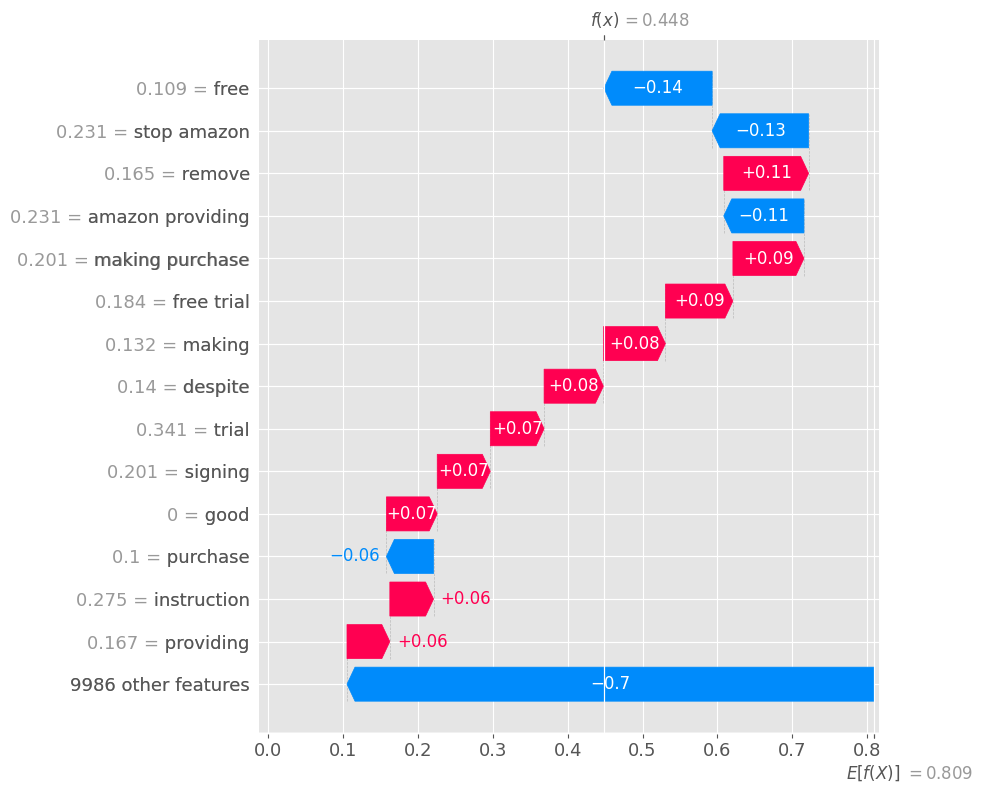

In [18]:
example_shap_raw = explainer(example_vector)

# Extract components for the single instance and selected class (e.g., Class 0)
# 'example_shap_raw' is already for a single instance from 'example_vector'
instance_values = example_shap_raw.values[0, :, 0] # Values for the first instance and Class 0
instance_base_value = example_shap_raw.base_values[0, 0] # Base value for the first instance and Class 0
instance_data = example_shap_raw.data[0] # Original data for the first instance (potentially sparse matrix row)

# Ensure base_value is a scalar float
if isinstance(instance_base_value, np.ndarray):
    instance_base_value = instance_base_value.item()

# Ensure instance_data is dense and 1D for plotting
if hasattr(instance_data, 'toarray'):
    instance_data_dense = instance_data.toarray().flatten() # Convert to dense and flatten to 1D
else:
    # If it's already a numpy array, ensure it's flattened to 1D if it has more than one dimension
    instance_data_dense = instance_data.flatten() if instance_data.ndim > 1 else instance_data

# Create a new Explanation object for this specific instance and class
single_explanation_for_waterfall_example = shap.Explanation(
    values=instance_values,
    base_values=instance_base_value,
    data=instance_data_dense, # Use dense and 1D data for plotting
    feature_names=tfidf.get_feature_names_out().tolist() # assuming tfidf is available
)

shap.plots.waterfall(
    single_explanation_for_waterfall_example,
    max_display=15
)

####Business Insight

#####Explaining misclassified reviews helps identify where the model struggles. For example, reviews containing sarcasm, mixed opinions, or ambiguous language may be incorrectly classified. These insights can guide future improvements, such as collecting more balanced training data or fine-tuning transformer-based models like BERT.

####Save Explainability Report

In [19]:
summary = pd.DataFrame({

"Figure":[

"Summary Plot",

"Bar Plot",

"Waterfall",

"Force Plot"

],

"Location":[

"outputs/shap/shap_summary.png",

"outputs/shap/shap_bar.png",

"outputs/shap/shap_waterfall.png",

"Interactive"

]

})

In [20]:
import os

# Create the directory if it does not exist
os.makedirs('outputs/reports', exist_ok=True)

summary.to_csv(

    "outputs/reports/shap_outputs.csv",

    index=False

)

####**Business Conclusions**

#####The SHAP analysis confirms that the sentiment classification model makes predictions based on meaningful textual features rather than arbitrary patterns. Keywords associated with delivery delays, product defects, refund requests, and customer service issues contribute strongly to negative sentiment, while terms related to quality, satisfaction, and recommendation drive positive predictions. This transparency increases confidence in the model and enables business stakeholders to understand not only what the model predicts, but why it makes those predictions.

####**Business Recommendations**

#####Prioritise operational improvements around the keywords most strongly associated with negative sentiment, such as delivery delays and refund processing.
#####Use SHAP explanations to support customer service teams when reviewing complex or disputed sentiment predictions.
#####Monitor changes in influential keywords over time to detect emerging customer concerns.
#####Incorporate SHAP analysis into future model validation to ensure the model continues to learn meaningful business patterns rather than spurious correlations.
#####Compare SHAP outputs after retraining the model to assess whether improvements in customer experience are reflected in the language driving sentiment.